In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 66.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pa

In [ ]:
import wfdb
import numpy as np

In [ ]:
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

signal = record.p_signal[:,0]  # single lead
ann_samples = annotation.sample
ann_symbols = annotation.symbol

In [ ]:
## Normalize ECG signal
signal = (signal - np.mean(signal)) / np.std(signal)


In [ ]:
# Label Mapping
label_map = {
    'N':0,  # Normal
    'L':1,  # LBBB
    'R':2,  # RBBB
    'V':3,  # PVC
    'A':4   # APC
}

In [ ]:
#Extract Beat Centered windows
WINDOW_SIZE = 256
HALF_WINDOW = WINDOW_SIZE // 2

X = []
y = []

for i in range(len(ann_samples)):
    sym = ann_symbols[i]

    if sym not in label_map:
        continue

    center = ann_samples[i]

    start = center - HALF_WINDOW
    end = center + HALF_WINDOW

    # skipping the boundary cases
    if start < 0 or end > len(signal):
        continue

    window = signal[start:end]

    X.append(window)
    y.append(label_map[sym])

X = np.array(X)
y = np.array(y)

In [ ]:
#Reshape for CNN

X = X.reshape(-1, WINDOW_SIZE, 1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,

)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

X_flat = X_train.reshape(len(X_train), -1)

ros = RandomOverSampler()
X_res, y_res = ros.fit_resample(X_flat, y_train)

X_res = X_res.reshape(-1, 256, 1)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_res)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_res
)

class_weights = dict(zip(classes, weights))


if 4 in class_weights:
    class_weights[4] *= 1.5

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(16, 5, activation='relu', input_shape=(WINDOW_SIZE,1)),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(32, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(64, 3, activation='relu'),
    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])
import tensorflow as tf

def focal_loss(gamma=2., alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=5)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)
        return -alpha * (1 - pt) ** gamma * tf.math.log(pt + 1e-8)
    return loss
model.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(
    X_res, y_res,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.3243e-04 - val_accuracy: 0.9890 - val_loss: 0.0086
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 1.1139e-04 - val_accuracy: 0.9890 - val_loss: 0.0088
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 8.9648e-05 - val_accuracy: 0.9890 - val_loss: 0.0091
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 8.5898e-05 - val_accuracy: 0.9912 - val_loss: 0.0106
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 6.4368e-05 - val_accuracy: 0.9890 - val_loss: 0.0099
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 5.2467e-05 - val_accuracy: 0.9890 - val_loss: 0.0103
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 4.3346e-05 - val_accuracy: 0.9912 - val_loss: 0.0111
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.00

In [ ]:
import os

model.save("model.h5")

size_kb = os.path.getsize("model.h5") / 1024
print(f"Model Size: {size_kb:.2f} KB")

Model Size: 175.15 KB


In [ ]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
import tensorflow as tf

def get_flops(model):
    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec([1,256,1], tf.float32)
    )

    frozen_func = convert_variables_to_constants_v2(concrete_func)

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(frozen_func.graph.as_graph_def(), name='')
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

flops = get_flops(model)
print("FLOPs:", flops)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


FLOPs: 1417854


In [ ]:
import time
import numpy as np
from sklearn.metrics import classification_report

latencies = []
y_pred = []

THRESHOLD = 0.6  # chnage this for tuning.

for x in X_test:
    x = x.reshape(1, 256, 1)

    start = time.time()

    #out = model.predict(x, verbose=0)
    out = model(x, training=False).numpy()

    latency = (time.time() - start) * 1000
    latencies.append(latency)

    # threshold-based prediction
    if out[0][4] > THRESHOLD:
        y_pred.append(4)
    else:
        y_pred.append(0)

y_pred = np.array(y_pred)

print(classification_report(y_test, y_pred))

print("\nAverage Latency:", np.mean(latencies), "ms")

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       448
           4       0.67      0.57      0.62         7

    accuracy                           0.99       455
   macro avg       0.83      0.78      0.80       455
weighted avg       0.99      0.99      0.99       455


Average Latency: 11.700547396481692 ms


In [ ]:
# Power estimation
energy_per_flop = 5e-12  # 5 picojoules per operation

energy = flops * energy_per_flop  # energy per inference

avg_latency_sec = np.mean(latencies) / 1000

power = energy / avg_latency_sec

print("Estimated Power:", power, "Watts")

Estimated Power: 0.0006058921655350685 Watts


TFLite COnversion


In [ ]:
import tensorflow as tf
tflite = tf.lite

def convert_to_tflite(model, X_sample):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    def representative_data():
        for i in range(100):
            yield [X_sample[i:i+1].astype('float32')]

    converter.representative_dataset = representative_data

    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open("model_int8.tflite", "wb") as f:
        f.write(tflite_model)

    print("TFLite model created!")

convert_to_tflite(model, X_train)


# load tflite model

interpreter = tflite.Interpreter(model_path="model_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

in_scale, in_zero = input_details[0]['quantization']
out_scale, out_zero = output_details[0]['quantization']

print("TFLite model loaded!")

# =========================
# SELECT BALANCED SAMPLES
# =========================
indices_0 = np.where(y_test == 0)[0]
indices_4 = np.where(y_test == 4)[0]

n0 = min(80, len(indices_0))
n4 = min(20, len(indices_4))

selected_indices = np.concatenate([indices_0[:n0], indices_4[:n4]])

print("Class 0 samples:", len(indices_0))
print("Class 4 samples:", len(indices_4))

# =========================
# WARM-UP (IMPORTANT)
# =========================
x = X_test[selected_indices[0]].reshape(1,256,1).astype(np.float32)

if input_details[0]['dtype'] == np.int8:
    x_q = (x / in_scale + in_zero).astype(np.int8)
else:
    x_q = x

for _ in range(50):
    interpreter.set_tensor(input_details[0]['index'], x_q)
    interpreter.invoke()

# =========================
# INFERENCE + LATENCY
# =========================
latencies_tfl = []
y_pred_tfl = []
y_true_tfl = []

THRESHOLD = 0.4
runs = 200

for i in selected_indices:
    x = X_test[i].reshape(1,256,1).astype(np.float32)
    y_true_tfl.append(y_test[i])

    if input_details[0]['dtype'] == np.int8:
        x_q = (x / in_scale + in_zero).astype(np.int8)
    else:
        x_q = x

    runs = 500

    #runs = 200
    lat_run = []

    for _ in range(runs):
      # add tiny noise to avoid caching
      x_noise = x_q.copy()

      start = time.perf_counter()

      interpreter.set_tensor(input_details[0]['index'], x_noise)
      interpreter.invoke()

      end = time.perf_counter()

      lat_run.append((end - start) * 1000)

    latency = np.mean(lat_run)
    latencies_tfl.append(latency)


    out = interpreter.get_tensor(output_details[0]['index'])

    if output_details[0]['dtype'] == np.int8:
        out = (out.astype(np.float32) - out_zero) * out_scale

    if out[0][4] > THRESHOLD:
        y_pred_tfl.append(4)
    else:
        y_pred_tfl.append(0)

# =========================
# RESULTS
# =========================
from sklearn.metrics import classification_report

print("\n=== TFLITE REPORT ===")
print(classification_report(y_true_tfl, y_pred_tfl))

print("TFLite Avg Latency:", np.mean(latencies_tfl), "ms")

Saved artifact at '/tmp/tmp61c3xm9m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138382928791888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138382928793040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138382928791696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138382928790352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138382928792464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138382928792080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138382928790544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138382928790928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138382928794384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138382928792656: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite model created!
TFLite model loaded!
Class 0 samples: 448
Class 4 samples: 7

=== TFLITE REPORT ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        80
           4       1.00      0.71      0.83         7

    accuracy                           0.98        87
   macro avg       0.99      0.86      0.91        87
weighted avg       0.98      0.98      0.98        87

TFLite Avg Latency: 0.06389657999979731 ms


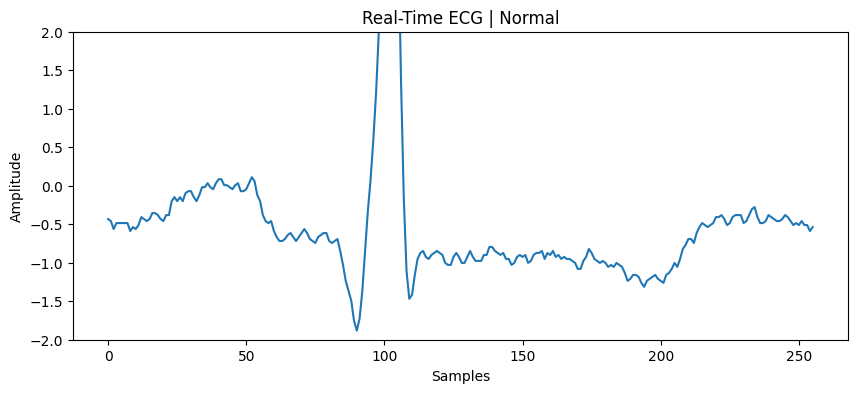


Recent Predictions:
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal
Normal


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import time
from IPython.display import clear_output

# streaming the data
def ecg_stream(signal, chunk_size=1):
    for i in range(0, len(signal), chunk_size):
        yield signal[i:i+chunk_size]


WINDOW_SIZE = 256
buffer = deque(maxlen=WINDOW_SIZE)

THRESHOLD = 0.4
ALERT_THRESHOLD = 5
alert_counter = 0

print("\n--- REAL-TIME ECG STREAM STARTED ---\n")


for sample in ecg_stream(signal):

    buffer.extend(sample)

    if len(buffer) == WINDOW_SIZE:

        # int8 i/p
        x = np.array(buffer).reshape(1,256,1).astype(np.float32)

        if input_details[0]['dtype'] == np.int8:
            x_q = (x / in_scale + in_zero).astype(np.int8)
        else:
            x_q = x

        # model
        interpreter.set_tensor(input_details[0]['index'], x_q)
        interpreter.invoke()

        out = interpreter.get_tensor(output_details[0]['index'])

        if output_details[0]['dtype'] == np.int8:
            out = (out.astype(np.float32) - out_zero) * out_scale

        # Graph
        clear_output(wait=True)

        plt.figure(figsize=(10,4))
        plt.plot(np.array(buffer))   # 🔥 FIX: convert to array
        plt.title("Real-Time ECG Signal")
        plt.ylim(-2,2)
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.show()

        # alert
        if out[0][4] > THRESHOLD:
            alert_counter += 1
        else:
            alert_counter = 0

        if alert_counter >= ALERT_THRESHOLD:
            print("🚨 ALERT: Continuous Abnormal ECG Detected!")
        elif out[0][4] > THRESHOLD:
            print("⚠️ Abnormal Beat")
        else:
            #print("Normal")
            # store prediction
            if alert_counter >= ALERT_THRESHOLD:
              pred = "🚨 ALERT"
            elif out[0][4] > THRESHOLD:
              pred = "⚠️ Abnormal"
            else:
              pred = "Normal"

          prediction_history.append(pred)

# show last 10 predictions
print("\nRecent Predictions:")
for p in prediction_history[-10:]:
    print(p)

        time.sleep(0.01)